
# Principal Component Analysis (PCA) on Iris Dataset

This example shows a well known decomposition technique known as Principal Component Analysis (PCA) on the [Iris dataset](https://en.wikipedia.org/wiki/Iris_flower_data_set).

This dataset is made of 4 features: sepal length, sepal width, petal length, petal width. We use PCA to project this 4 feature space into a 3-dimensional space.


In [1]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

## Loading the Iris dataset

The Iris dataset is directly available as part of scikit-learn. It can be loaded using the :func:`~sklearn.datasets.load_iris` function. With the default parameters, a :class:`~sklearn.utils.Bunch` object is returned, containing the data, the target values, the feature names, and the target names.



In [2]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


## Plot of pairs of features of the Iris dataset

Let's first plot the pairs of features of the Iris dataset.



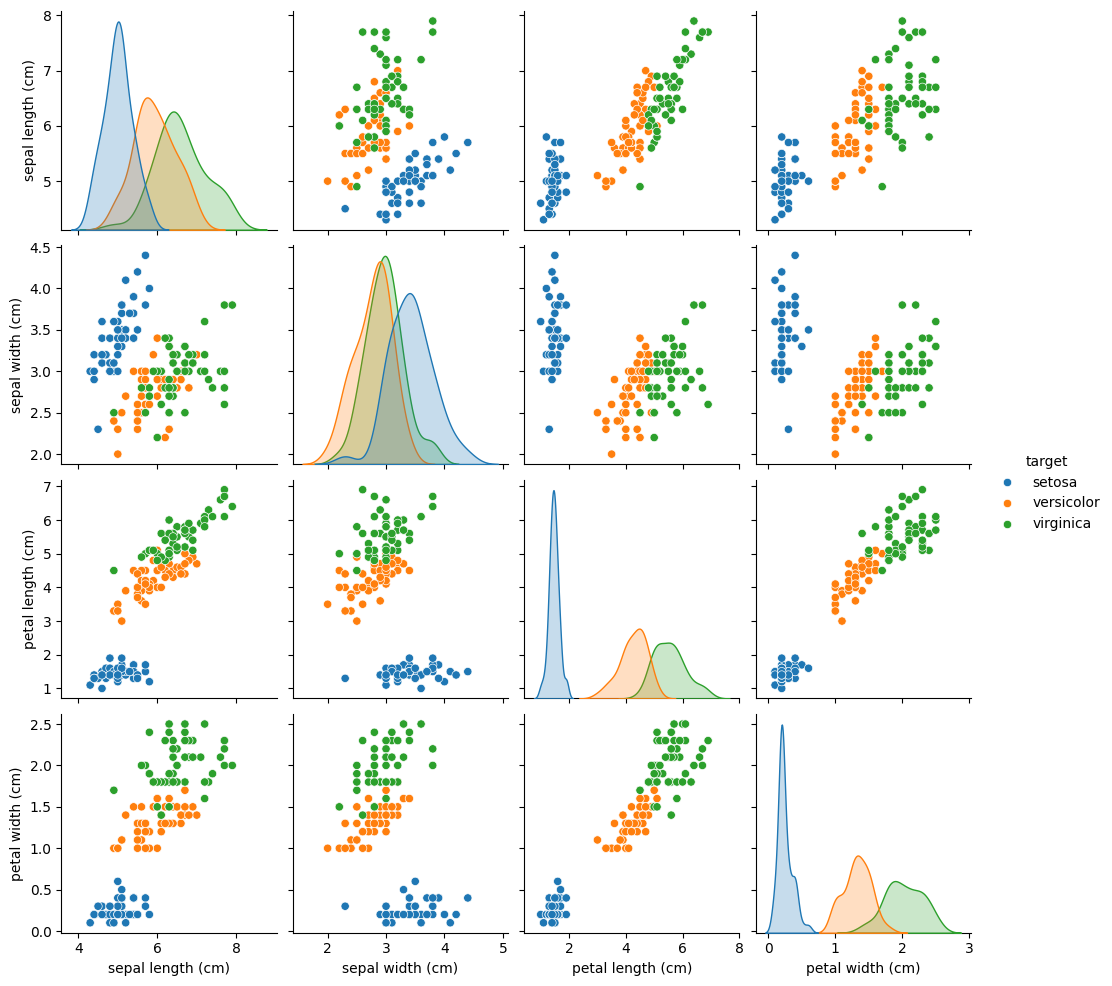

In [3]:
import seaborn as sns

# Rename classes using the iris target names
iris.frame["target"] = iris.target_names[iris.target]
_ = sns.pairplot(iris.frame, hue="target")

Each data point on each scatter plot refers to one of the 150 iris flowers in the dataset, with the color indicating their respective type(Setosa, Versicolor, and Virginica).

You can already see a pattern regarding the Setosa type, which is easily identifiable based on its short and wide sepal. Only considering these two dimensions, sepal width and length, there's still overlap between the Versicolor and Virginica types.

The diagonal of the plot shows the distribution of each feature. We observe that the petal width and the petal length are the most discriminant features for the three types.

## Plot a PCA representation
Let's apply a Principal Component Analysis (PCA) to the iris dataset and then plot the irises across the first three principal components. This will allow us to better differentiate among the three types!



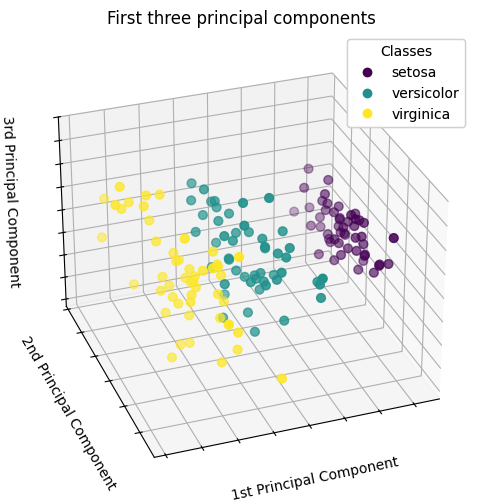

In [4]:
import matplotlib.pyplot as plt

# unused but required import for doing 3d projections with matplotlib < 3.2
import mpl_toolkits.mplot3d  # noqa: F401

from sklearn.decomposition import PCA

fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

pca = PCA()
X_reduced = pca.fit_transform(iris.data)
scatter = ax.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    X_reduced[:, 2],
    c=iris.target,
    s=40,
)

ax.set(
    title="First three principal components",
    xlabel="1st Principal Component",
    ylabel="2nd Principal Component",
    zlabel="3rd Principal Component",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

# Add a legend
legend1 = ax.legend(
    scatter.legend_elements()[0],
    iris.target_names.tolist(),
    loc="upper right",
    title="Classes",
)
ax.add_artist(legend1)

plt.show()

PCA will create 3 new features that are a linear combination of the 4 original features. In addition, this transformation maximizes the variance. With this transformation, we can identify each species using only the first principal component.


## Extra stuff

In [ ]:
import numpy as np

# PCA is eigendecomposition!
X_centred = iris.data - iris.data.mean(axis = 0)
C =  np.cov(X_centred, rowvar=False)
Lambda, Q = np.linalg.eig(C)
print(Lambda)
print(pca.explained_variance_)

# eigenvalues are columns, pca components are rows for some reason
print(Q)
print(pca.components_.T)


[4.22824171 0.24267075 0.0782095  0.02383509]
[4.22824171 0.24267075 0.0782095  0.02383509]
[[ 0.36138659 -0.65658877 -0.58202985  0.31548719]
 [-0.08452251 -0.73016143  0.59791083 -0.3197231 ]
 [ 0.85667061  0.17337266  0.07623608 -0.47983899]
 [ 0.3582892   0.07548102  0.54583143  0.75365743]]
[[ 0.36138659  0.65658877 -0.58202985  0.31548719]
 [-0.08452251  0.73016143  0.59791083 -0.3197231 ]
 [ 0.85667061 -0.17337266  0.07623608 -0.47983899]
 [ 0.3582892  -0.07548102  0.54583143  0.75365743]]


,0,1,2,3
0,2.818240,-5.646350,-0.659768,-0.031089
1,2.788223,-5.149951,-0.842317,0.065675
2,2.613375,-5.182003,-0.613952,-0.013383
3,2.757022,-5.008654,-0.600293,-0.108928
4,2.773649,-5.653707,-0.541773,-0.094610
...,...,...,...,...
145,7.446475,-5.514485,-0.454028,0.392844
146,7.029532,-4.951636,-0.753751,0.221016
147,7.266711,-5.405811,-0.501371,0.103650
148,7.403307,-5.443581,0.091399,0.011244


Text(0, 0.5, '2nd Principal Component')

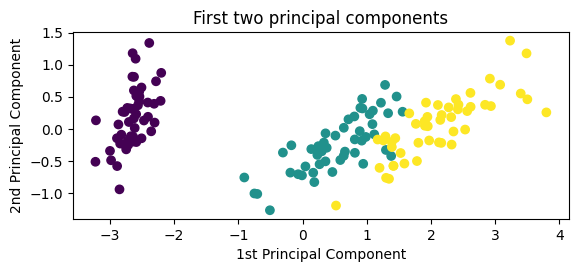

In [31]:
# look at just the first two components
fig, ax = plt.subplots()
ax.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    c=iris.target
)
ax.set_aspect("equal")
plt.title("First two principal components")
plt.xlabel("1st Principal Component")
plt.ylabel("2nd Principal Component")  

Text(0, 0.5, '2nd Principal Component')

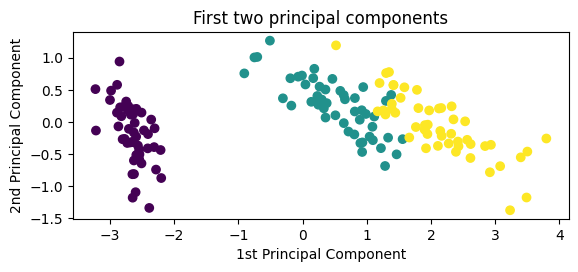

In [ ]:
# eigenvalue version - same, just flipped
X_eig = (X_centred @ Q).values
fig, ax = plt.subplots()
ax.scatter(
    X_eig[:, 0],
    X_eig[:, 1],
    c=iris.target
)
ax.set_aspect("equal")
plt.title("First two principal components")
plt.xlabel("1st Principal Component")
plt.ylabel("2nd Principal Component") 

In [ ]:
# Plot the explained variance ratio
plt.figure()
plt.plot(range(1, 5), pca.explained_variance_ratio_)
plt.ylabel("Variance explained")
plt.xlabel("Component")

In [ ]:
# What is that first one?
plt.bar(range(4), pca.components_[0], width=0.2)
plt.xticks(range(4), iris.feature_names, rotation=45)
plt.ylabel("Weight")

## LDA
Linear Discriminant Analysis (LDA) is similar, but maximizes between-class variance instead of overall variance.

In [ ]:
# What about LDA instead?
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()
X_lda = lda.fit_transform(iris.data, iris.target)
fig, ax = plt.subplots()
ax.scatter(
    X_lda[:, 0],
    X_lda[:, 1],
    c=iris.target
)
ax.set_aspect("equal")

In [ ]:
# Compare PCA and LDA weights
plt.bar(np.arange(4)-0.1, pca.components_[0], width=0.2, label="PCA")
plt.bar(np.arange(4)+0.1, lda.coef_[0] / lda.coef_[0].sum(), width=0.2, label="LDA")
plt.xticks(range(4), iris.feature_names, rotation=45)
plt.ylabel("Weight")
plt.legend()

In [ ]:
# Plot the explained variance ratio
plt.figure()
plt.plot(range(1, 5), pca.explained_variance_ratio_, label="PCA")
plt.plot(range(1, 3), lda.explained_variance_ratio_, "o", label="LDA")
plt.ylabel("Variance explained")
plt.xlabel("Component")
plt.legend()